<a href="https://colab.research.google.com/github/PabloXberg/Project-3-Ironhack/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Preprocessing & Visualization

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


Sample images from the dataset:


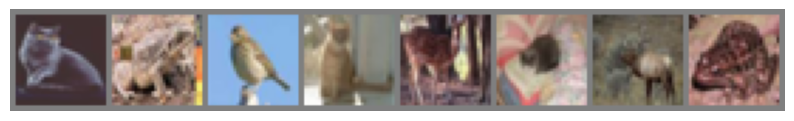

cat   frog  bird  cat   deer  cat   deer  frog 


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Data Preprocessing & Augmentation
# We add a random flip to the training data to prevent overfitting
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalizes pixel values
])

# Test data shouldn't be augmented, just converted and normalized
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Download and Load Data
print("Downloading datasets...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# CIFAR-10 Classes
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 3. Visualization for your PPT
def imshow(img):
    img = img / 2 + 0.5     # unnormalize back to [0, 1] for viewing
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images (just the first 8 for a clean picture)
print("Sample images from the dataset:")
imshow(torchvision.utils.make_grid(images[:8]))
# Print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

Step 2: Building your Custom CNN

3 Convolutional Layers (to extract features like edges, shapes, and textures from the images).

Max Pooling Layers (to shrink the image size down and make the network run faster).

2 Fully Connected (Linear) Layers (to make the final decision on which of the 10 categories the image belongs to).

Dropout (a neat trick that randomly turns off some neurons during training to prevent "overfitting," which is when the model just memorizes the data instead of actually learning).

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        # 1st Convolutional Layer: 3 input channels (RGB images), 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # 2nd Convolutional Layer: 32 input channels, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # 3rd Convolutional Layer: 64 input channels, 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Max pooling layer: reduces image dimensions by half
        self.pool = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        # The image starts at 32x32. After 3 pooling layers, it's 4x4.
        # 128 filters * 4 * 4 = 2048 flattened features
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        # Output layer: 10 classes for CIFAR-10
        self.fc2 = nn.Linear(512, 10)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Pass through Conv layers, apply ReLU activation, then Pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the data for the Fully Connected layers
        x = x.view(-1, 128 * 4 * 4)

        # Pass through FC layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x) # No activation here, CrossEntropyLoss does that for us
        return x

# Instantiate the model and move it to the GPU we set up earlier
custom_model = CustomCNN().to(device)

# Print the model architecture to confirm
print("Custom CNN Architecture:")
print(custom_model)

Custom CNN Architecture:
CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


Step 3: Model Training

In [4]:
import torch.optim as optim
import time

# 1. Define Loss Function
# CrossEntropyLoss is the standard for multi-class classification problems
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer
# Adam optimizer adapts the learning rate during training for faster convergence
optimizer_custom = optim.Adam(custom_model.parameters(), lr=0.001)

# 3. Create a Reusable Training Function with Early Stopping
def train_model(model, optimizer, num_epochs=15, patience=3):
    print(f"Starting training for {model.__class__.__name__}...")
    start_time = time.time()

    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0

        # --- TRAINING PASS ---
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # Clear old gradients

            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels) # Calculate loss
            loss.backward() # Backward pass (calculate gradients)
            optimizer.step() # Update weights

            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)
        train_losses.append(avg_train_loss)

        # --- VALIDATION PASS ---
        model.eval() # Set model to evaluation mode (turns off dropout)
        val_loss = 0.0
        with torch.no_grad(): # Turn off gradient calculation to save memory/time
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(testloader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best model weights to a file
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
                break

    # Load the best weights back into the model before returning
    model.load_state_dict(torch.load('best_model.pth'))
    print(f"Training completed in {(time.time() - start_time)/60:.2f} minutes.")
    return train_losses, val_losses

# 4. RUN IT!
# We set it to 15 max epochs, but early stopping will likely catch it before then.
custom_train_losses, custom_val_losses = train_model(custom_model, optimizer_custom, num_epochs=15, patience=3)

Starting training for CustomCNN...
Epoch [1/15] | Train Loss: 1.3862 | Val Loss: 1.0958
Epoch [2/15] | Train Loss: 0.9714 | Val Loss: 0.8768
Epoch [3/15] | Train Loss: 0.8086 | Val Loss: 0.7986
Epoch [4/15] | Train Loss: 0.6985 | Val Loss: 0.7418
Epoch [5/15] | Train Loss: 0.6318 | Val Loss: 0.7033
Epoch [6/15] | Train Loss: 0.5630 | Val Loss: 0.7023
Epoch [7/15] | Train Loss: 0.5207 | Val Loss: 0.6664
Epoch [8/15] | Train Loss: 0.4730 | Val Loss: 0.6404
Epoch [9/15] | Train Loss: 0.4387 | Val Loss: 0.6424
Epoch [10/15] | Train Loss: 0.4044 | Val Loss: 0.6447
Epoch [11/15] | Train Loss: 0.3723 | Val Loss: 0.6292
Epoch [12/15] | Train Loss: 0.3410 | Val Loss: 0.6770
Epoch [13/15] | Train Loss: 0.3180 | Val Loss: 0.6816
Epoch [14/15] | Train Loss: 0.3009 | Val Loss: 0.6948

Early stopping triggered! No improvement for 3 epochs.
Training completed in 4.12 minutes.


Step 4: Model Evaluation (Metrics & Confusion Matrix)

Evaluating Custom CNN...

--- Classification Report for Custom CNN ---
              precision    recall  f1-score   support

       plane       0.83      0.82      0.83      1000
         car       0.92      0.88      0.90      1000
        bird       0.77      0.70      0.74      1000
         cat       0.61      0.64      0.63      1000
        deer       0.77      0.76      0.76      1000
         dog       0.70      0.74      0.72      1000
        frog       0.83      0.87      0.85      1000
       horse       0.89      0.79      0.84      1000
        ship       0.87      0.90      0.88      1000
       truck       0.83      0.89      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



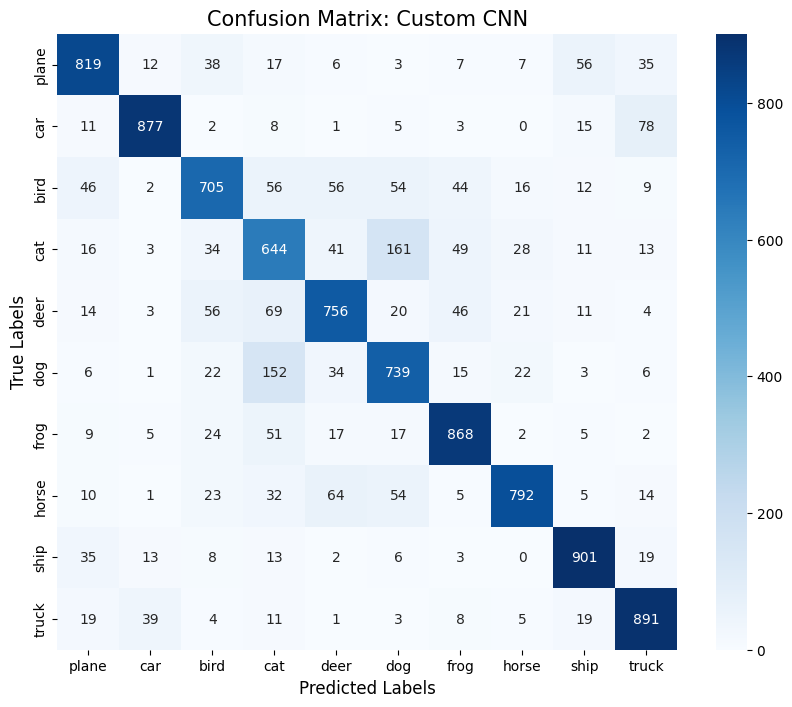

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataloader, model_name):
    print(f"Evaluating {model_name}...")
    model.eval() # Set model to evaluation mode

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1) # Get the index of the highest probability

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Print Classification Report (Accuracy, Precision, Recall, F1)
    print(f"\n--- Classification Report for {model_name} ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=15)
    plt.show()

# Run the evaluation on our Custom CNN using the test data
evaluate_model(custom_model, testloader, "Custom CNN")